<a href="https://colab.research.google.com/github/DzhuJK/ML/blob/main/%D0%9B%D0%A02_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_2_%D0%9B%D0%B0%D1%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2.2. Лац, 4-8

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [6]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


The dataset typically includes the following columns:

PassengerId: A unique identifier for each passenger.

Survived: This column indicates whether a passenger survived (1) or did not survive (0).

Pclass (Ticket class): A proxy for socio-economic status, with 1 being the highest class and 3 the lowest.

Name: The name of the passenger.

Sex: The gender of the passenger.

Age: The age of the passenger. (Note: There might be missing values in this column.)

SibSp: The number of siblings or spouses the passenger had aboard the Titanic.

Parch: The number of parents or children the passenger had aboard the Titanic.

Ticket: The ticket number.

Fare: The amount of money the passenger paid for the ticket.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1, inplace=True)

In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [15]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [16]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_4220/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [17]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [18]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [19]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [20]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


In [21]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [22]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


In [23]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


Виживання у першому класі значно вище, ніж у третьому

In [24]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Вік не мав сильного впливу на виживання

In [25]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
    print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_4220/1421978565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


Чим дорожчий квиток, тим вищий шанс на виживання

In [26]:
for i in range(1, 4):
    median_fare = df[df['Pclass'] == i]['Fare'].median()
    print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Вартість квитка сильно залежала від класу

<Axes: xlabel='Age', ylabel='Count'>

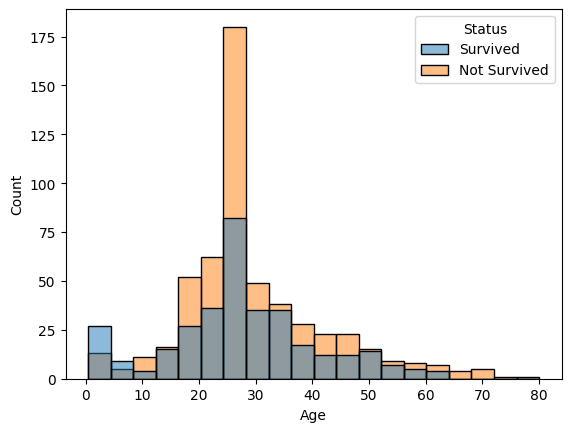

In [27]:
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

Віковий фактор мав вплив лише для дітей, а для дорослих і літніх пасажирів вирішальними були інші змінні — стать та клас квитка

In [32]:
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male" if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


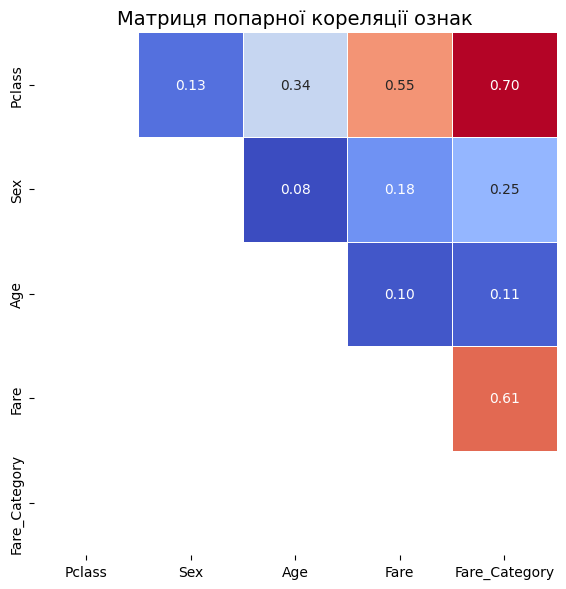

In [34]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Завдання 2

In [37]:
import pandas as pd
import requests
from io import StringIO

url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C"

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [39]:
df.columns

Index(['Регіон', '1950', '1960', '1970', '1990', '2000', '2012', '2014',
       '2019'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регіон  28 non-null     object 
 1   1950    26 non-null     float64
 2   1960    27 non-null     float64
 3   1970    27 non-null     float64
 4   1990    28 non-null     float64
 5   2000    28 non-null     float64
 6   2012    28 non-null     float64
 7   2014    28 non-null     object 
 8   2019    28 non-null     object 
dtypes: float64(6), object(3)
memory usage: 2.1+ KB


In [42]:
df.isnull().sum()

,0
Регіон,0
1950,2
1960,1
1970,1
1990,0
2000,0
2012,0
2014,0
2019,0


In [43]:
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna(df.median(numeric_only=True))

In [44]:
df.isnull().sum()

,0
Регіон,0
1950,0
1960,0
1970,0
1990,0
2000,0
2012,0
2014,0
2019,0


In [45]:
df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,float64
2000,float64
2012,float64
2014,object
2019,object


In [46]:
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.000000,20.600000,16.000000,13.0,7.3,12.6,—,—
1,Вінницька,22.400000,19.200000,14.200000,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.700000,25.000000,17.900000,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.400000,20.400000,15.100000,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.100000,21.400000,14.000000,10.9,6.1,9.8,8.2,—
5,Житомирська,26.100000,22.300000,15.900000,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.400000,27.300000,20.700000,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.900000,19.700000,15.000000,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.300000,24.800000,18.200000,15.5,10.3,12.4,12.2,8.8
9,Київська,20.400000,18.900000,15.600000,12.3,7.3,12.2,12.1,8.0


In [64]:
df = df.replace("—", np.nan)

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in df.columns[1:]:
    df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

Регіон    0
1950      0
1960      0
1970      0
1990      0
2000      0
2012      0
2014      0
2019      0
dtype: int64


In [65]:
df.tail()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
23,Чернівецька,24.700000,21.800000,17.000000,14.8,10.1,12.8,12.900000,9.200000
24,Чернігівська,22.000000,18.300000,12.700000,10.8,6.9,9.4,9.000000,6.100000
25,Київ,23.092308,17.400000,15.900000,12.0,7.3,12.0,12.100000,11.000000
26,Севастополь,23.092308,20.748148,15.585185,12.5,7.0,12.0,11.142308,8.020833
27,Україна,22.800000,20.500000,15.200000,12.6,7.8,11.4,11.100000,8.100000


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.describe()

,1950,1960,1970,1990,2000,2012,2014,2019
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,23.092308,20.748148,15.585185,13.042857,8.207143,11.646429,11.142308,8.020833
std,2.715514,2.881148,1.835394,1.527872,1.556808,1.636274,1.935664,1.338595
min,18.600000,16.300000,12.700000,10.800000,6.100000,9.400000,5.100000,6.000000
25%,21.250000,18.775000,14.400000,12.225000,7.075000,10.450000,10.475000,7.025000
50%,22.900000,20.450000,15.350000,12.600000,7.850000,11.450000,11.142308,8.010417
75%,24.400000,21.925000,16.150000,14.050000,8.950000,12.250000,12.100000,8.725000
max,31.400000,27.300000,20.700000,16.800000,11.800000,15.900000,14.800000,11.000000


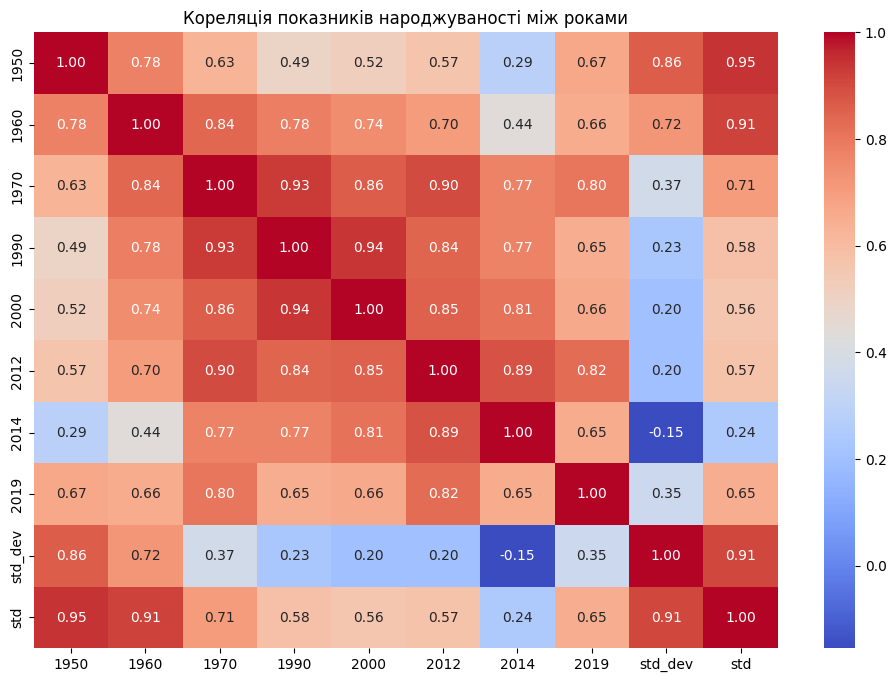

In [73]:
part = df.select_dtypes(include=['float', 'int'])
corr = part.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляція показників народжуваності між роками")
plt.show()

In [71]:
df['std'] = df.iloc[:, 1:].std(axis=1)
max_std = df['std'].max()

region = df[df['std'] == max_std]['Регіон'].values[0]

print(f'{region} має найбільше стандартне відхилення: {max_std}')
df.head(10)


Закарпатська має найбільше стандартне відхилення: 8.019498491015547


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019,std_dev,std
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.142308,8.020833,5.610101,6.032349
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900000,7.600000,5.153484,5.646884
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100000,10.100000,5.611707,6.678913
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100000,7.100000,5.221231,5.635924
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200000,8.020833,7.369561,6.963048
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.000000,7.900000,6.389444,6.629251
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.600000,10.400000,7.492425,8.019498
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.600000,6.800000,5.519171,5.778511
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.200000,8.800000,6.128024,6.717559
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.100000,8.000000,4.702279,5.446806


In [72]:
top_regions = df.sort_values(by=df.columns[-1], ascending=False).head(5)
bottom_regions = df.sort_values(by=df.columns[-1]).head(5)

print("ТОП-5 регіонів за народжуваністю:")
print(top_regions)

print("\nНАЙНИЖЧІ показники:")
print(bottom_regions)

ТОП-5 регіонів за народжуваністю:
               Регіон  1950  1960  1970  1990  2000  2012  2014       2019  \
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.400000   
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   8.020833   
16         Рівненська  26.9  26.7  19.3  15.8  11.8  15.9  14.8  10.700000   
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   8.020833   
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.800000   

     std_dev       std  
6   7.492425  8.019498  
11  7.868236  7.298552  
16  6.178982  7.206142  
4   7.369561  6.963048  
8   6.128024  6.717559  

НАЙНИЖЧІ показники:
            Регіон  1950  1960  1970  1990  2000  2012  2014  2019   std_dev  \
15      Полтавська  18.6  16.3  13.1  11.8   7.0   9.9  10.0   6.5  4.242304   
19      Харківська  19.7  17.3  14.0  11.4   6.8   9.9  10.1   6.8  4.687979   
22       Черкаська  20.5  17.9  14.4  12.3   7.5  10.0   9.8   6.4  4.962430   
10  Кі

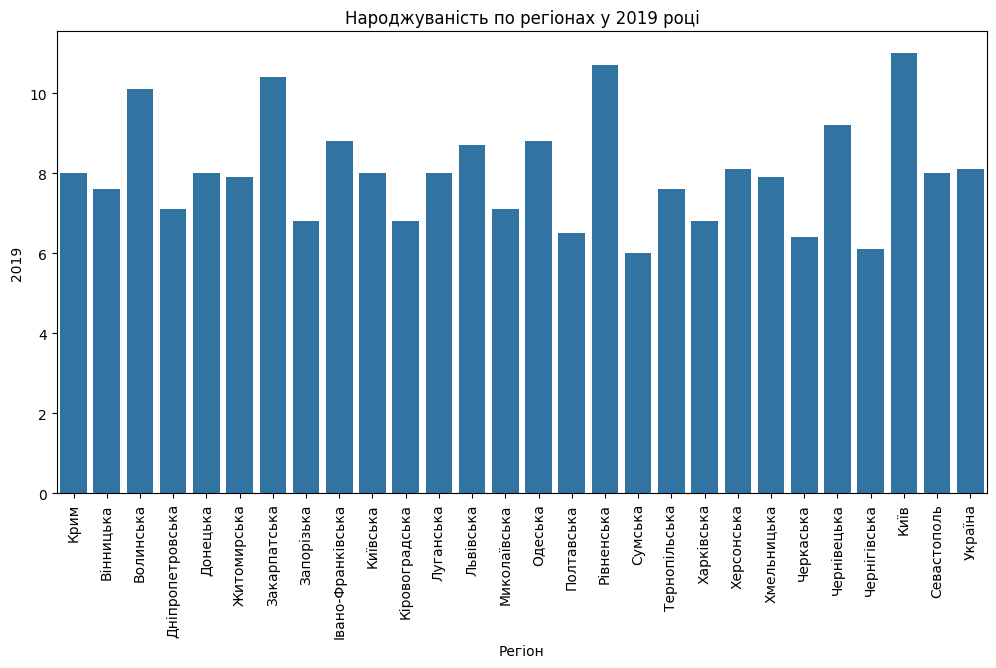

In [75]:
plt.figure(figsize=(12,6))
sns.barplot(x="Регіон", y="2019", data=df)
plt.xticks(rotation=90)
plt.title("Народжуваність по регіонах у 2019 році")
plt.show()

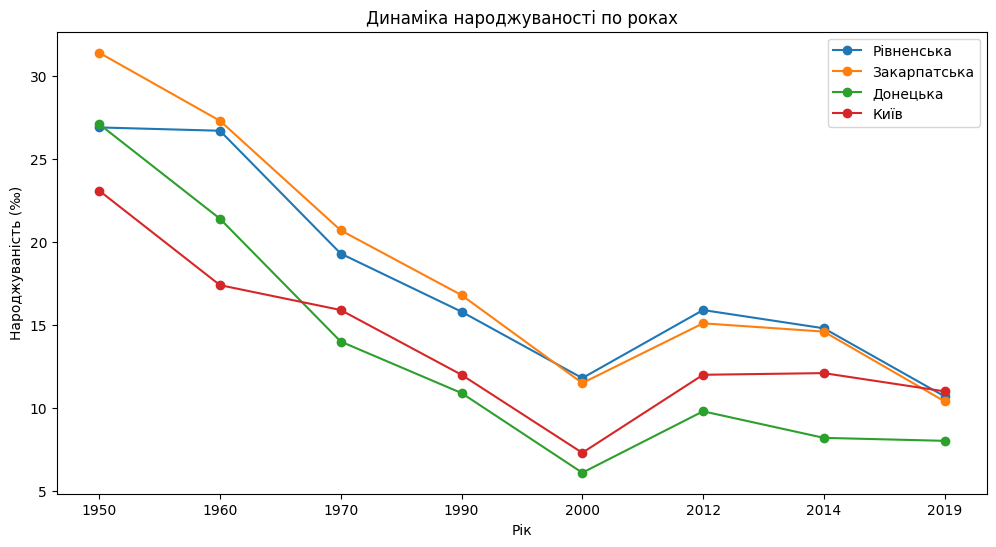

In [76]:
years = ["1950","1960","1970","1990","2000","2012","2014","2019"]

plt.figure(figsize=(12,6))
for region in ["Рівненська","Закарпатська","Донецька","Київ"]:
    plt.plot(years, df.loc[df["Регіон"]==region, years].values[0], marker="o", label=region)

plt.title("Динаміка народжуваності по роках")
plt.xlabel("Рік")
plt.ylabel("Народжуваність (‰)")
plt.legend()
plt.show()

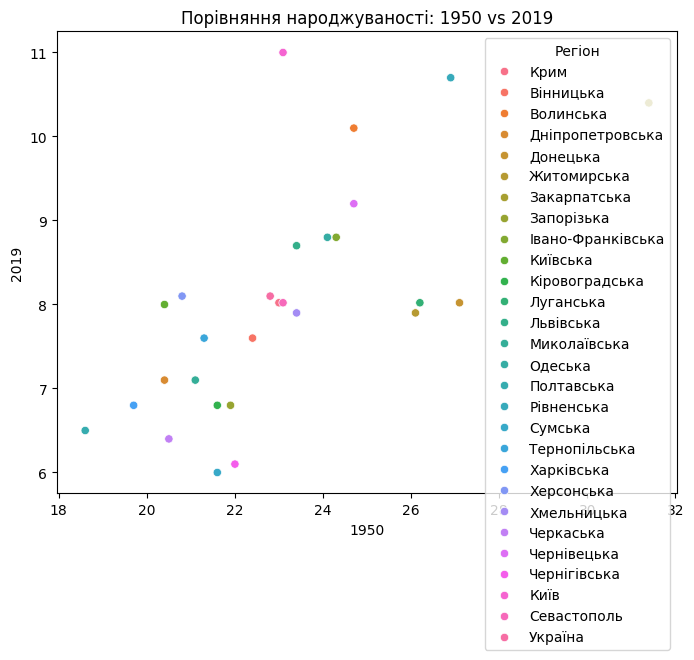

In [78]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["1950"], y=df["2019"], hue=df["Регіон"])
plt.title("Порівняння народжуваності: 1950 vs 2019")
plt.xlabel("1950")
plt.ylabel("2019")
plt.show()

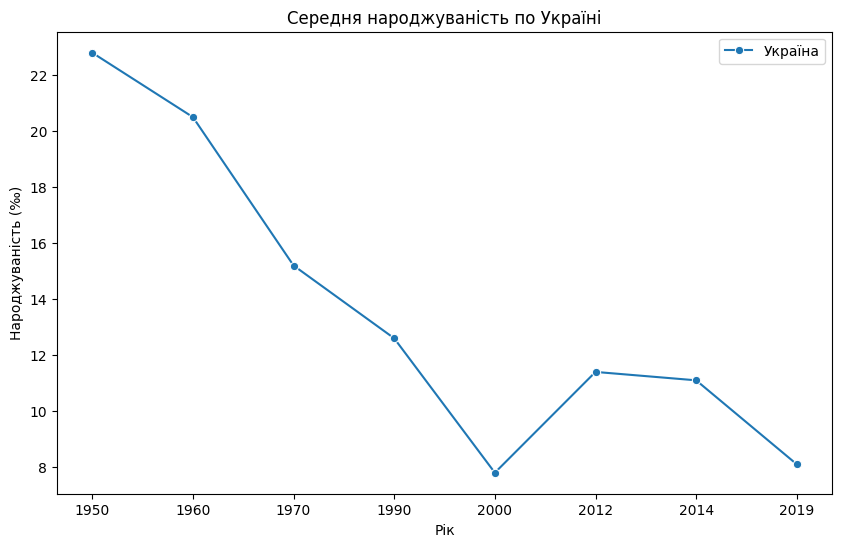

In [79]:
years = ["1950","1960","1970","1990","2000","2012","2014","2019"]

avg_birth = df[df["Регіон"]=="Україна"][years].astype(float).T
avg_birth.columns = ["Україна"]

plt.figure(figsize=(10,6))
sns.lineplot(data=avg_birth, marker="o")
plt.title("Середня народжуваність по Україні")
plt.xlabel("Рік")
plt.ylabel("Народжуваність (‰)")
plt.show()